基础对比代码

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
from mindquantum.core.circuit import Circuit, UN
from mindquantum.core.gates import H, X, RY, RX, Measure, PhaseShift, SWAP
from mindquantum.algorithm.library import qft
from mindquantum.simulator import Simulator
from IPython.display import display

plt.rcParams['font.sans-serif'] = ['SimHei']   
plt.rcParams['axes.unicode_minus'] = False     

# ==================== 1. 参数设置 ====================
num_qpe_qubits = 3       
target_qubit = 3         
ancilla_qubit = 4        
total_qubits = 5         

# [模块 A] 状态制备
circ_prep = Circuit()

# [模块 B] 量子相位估算 (QPE) - 严格同步第一个代码的参数
circ_qpe = Circuit()
circ_qpe += UN(H, range(num_qpe_qubits)) 
for k in range(num_qpe_qubits):
    # 保持 k-2 确保特征值1和3完美映射为时钟寄存器的整数1和3
    tau = np.pi * (2**(k - 2))  
    circ_qpe += PhaseShift(2 * tau).on(k)
    circ_qpe += RX(-2 * tau).on(target_qubit, k) 

# [模块 D] 穷举求逆 - 严格同步第一个代码的逻辑
circ_inv = Circuit()
qc = [0, 1, 2]       
qs = ancilla_qubit   
C = 1.0              

for k in range(1, 2**num_qpe_qubits):  
    lam = float(k)
    ratio = C / lam
    if ratio > 1.0: ratio = 1.0 
    angle = 2 * np.arcsin(ratio) 
    
    for i in range(num_qpe_qubits):
        if (k & (1 << i)) == 0:
            circ_inv += X.on(qc[i])
            
    circ_inv += RY(angle).on(qs, qc) 
    
    for i in range(num_qpe_qubits):
        if (k & (1 << i)) == 0:
            circ_inv += X.on(qc[i])

# ==================== 2. 新型 IQFT 模块化构建 ====================

def cz_and_swap(q_control, q_target, rot):
    c = Circuit()
    c += PhaseShift(np.pi * rot).on(q_target, q_control)
    c += SWAP.on([q_control, q_target])
    return c

def get_novel_iqft_3():
    c = Circuit()
    # 严格对齐：a=2(高位), b=1, d=0(低位)
    a, b, d = 2, 1, 0
    
    # 第 1 轮
    c += H.on(a)
    c += cz_and_swap(a, b, 0.5)
    c += cz_and_swap(b, d, 0.25)
    
    # 第 2 轮
    c += H.on(a)
    c += cz_and_swap(a, b, 0.5)
    
    # 第 3 轮
    c += H.on(a)
    
    # 返回其共轭转置作为逆变换
    return c.hermitian()

# 核心比对定义
circ_iqft_novel = get_novel_iqft_3()
circ_iqft_std = qft([2, 1, 0]).hermitian() # 标准库对比项

# ==================== 3. 执行测试与比对 ====================
def run_comparison(total_shots=100000):
    results = {}
    circuits_to_test = {
        "Standard_HHL": circ_iqft_std,
        "Novel_HHL": circ_iqft_novel
    }
    
    for name, iqft_module in circuits_to_test.items():
        full_circ = circ_prep + circ_qpe + iqft_module + circ_inv + iqft_module.hermitian() + circ_qpe.hermitian()
        
        print(f"\n>>>>>>>>>>>>>>>> 正在生成 {name} 线路图 <<<<<<<<<<<<<<<<")
        display(full_circ.svg())
        
        # 添加测量
        full_circ += Measure('sol_q3').on(target_qubit) 
        full_circ += Measure('aux_q4').on(ancilla_qubit)
        
        sim = Simulator('mqvector', total_qubits)
        start_time = time.time()  
        result = sim.sampling(full_circ, shots=total_shots)
        elapsed_time = time.time() - start_time
        
        # 后处理
        valid_counts = {k: v for k, v in result.data.items() if k.startswith('1')}
        total_valid_shots = sum(valid_counts.values())
        
        if total_valid_shots > 0:
            reconstructed_vector = np.zeros(2)
            for state, count in valid_counts.items():
                solution_state = state[1:]  
                prob = count / total_valid_shots
                reconstructed_vector[int(solution_state, 2)] = np.sqrt(prob)
                
            reconstructed_vector = reconstructed_vector / np.linalg.norm(reconstructed_vector)
            
            scale_factor = (np.sqrt(total_valid_shots / total_shots) * 1.0) / C
            final_solution = reconstructed_vector * scale_factor
            
            results[name] = {
                'time': elapsed_time,
                'solution': np.round(final_solution, 4)
            }
        else:
            print(f"{name} 采样失败")
            
    print("\n================ 性能提升综合报告 ================")
    print(f"理论数学解:      [0.6667 -0.3333]")
    for name in circuits_to_test.keys():
        print(f"计算得出的解:    {results[name]['solution']}  ")
    print("-" * 50)

if __name__ == '__main__':
    run_comparison(total_shots=100000)

第一章对比图1

开始模拟 (采样 100000 次)...
耗时: 0.0929 秒

解状态 |0> : 采样次数   56257 次 | 相对概率约 89.89%
解状态 |1> : 采样次数    6330 次 | 相对概率约 10.11%

辅助比特成功率 P(success): 62.59%
量子重建绝对值:  [0.75   0.2516]

正在生成对比图表...
图片已保存至当前目录 (HHL_Result_Comparison.png 和 .pdf)


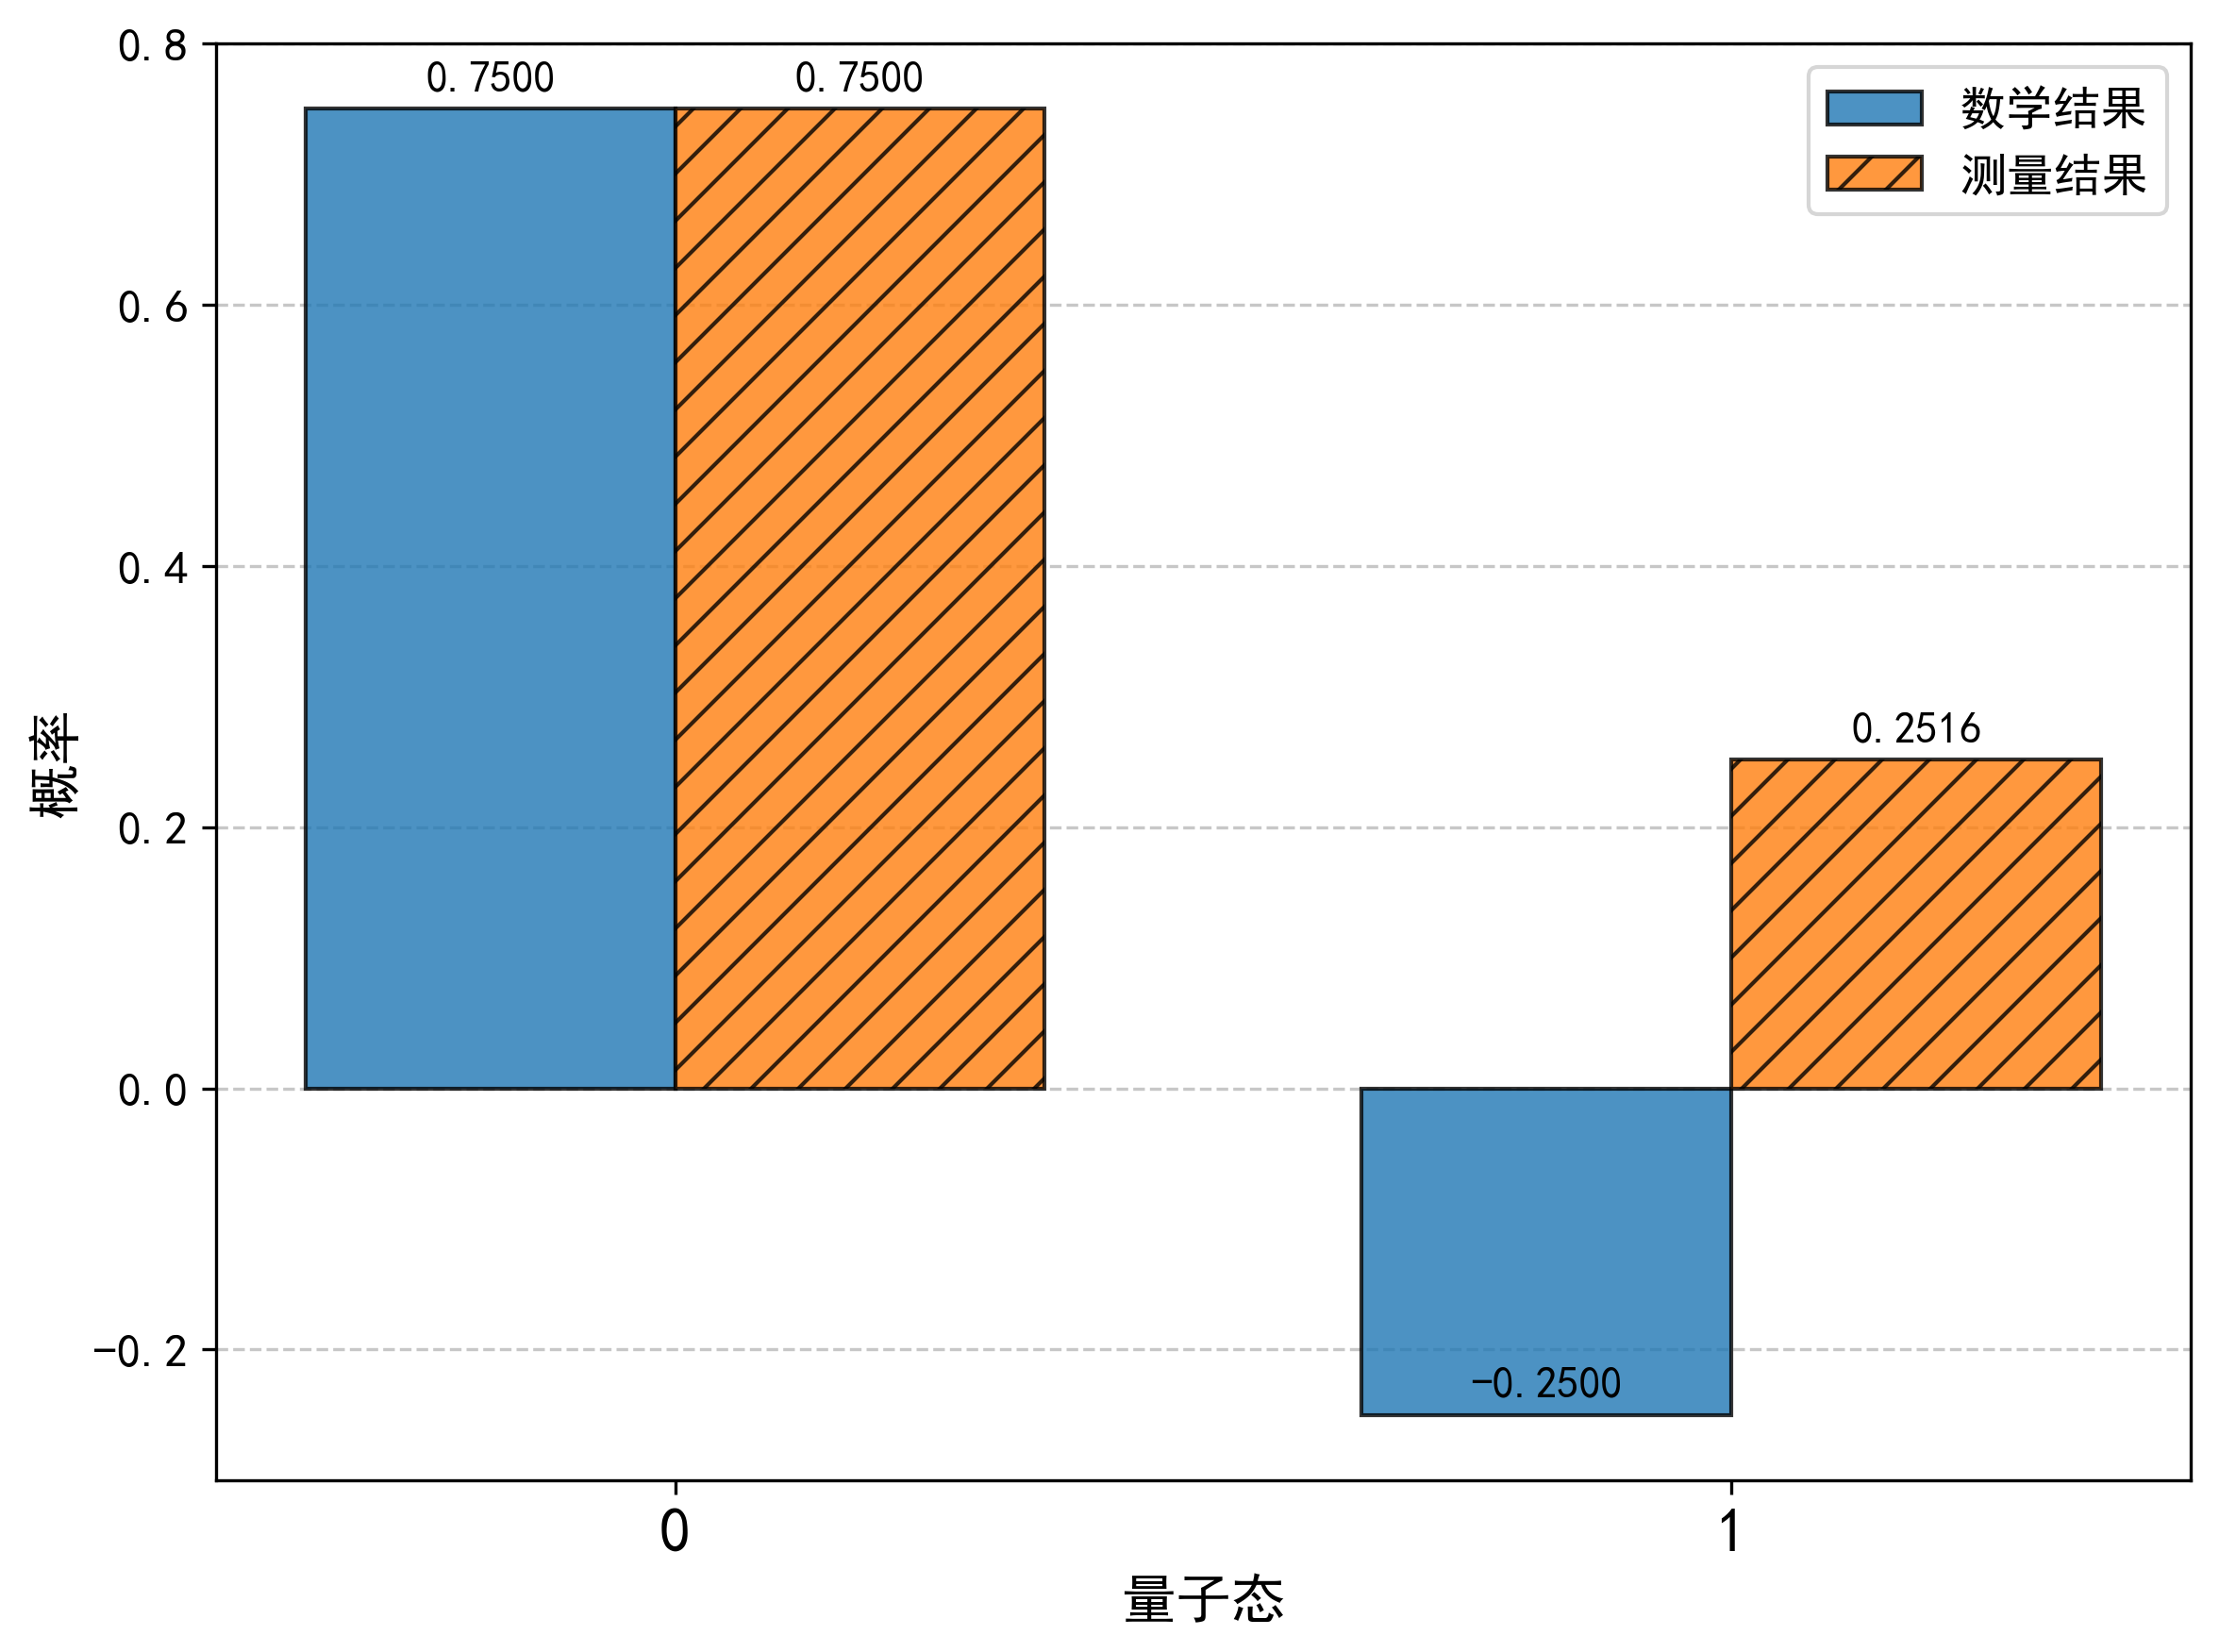

In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt
from mindquantum.core.circuit import Circuit, UN
from mindquantum.core.gates import H, X, RY, RX, Measure, PhaseShift
from mindquantum.algorithm.library import qft
from mindquantum.simulator import Simulator
plt.rcParams['font.sans-serif'] = ['SimHei']   # 用来正常显示中文（黑体）
plt.rcParams['axes.unicode_minus'] = False     # 用来正常显示负号

# ==================== 1. 参数设置 ====================
num_qpe_qubits = 2       
num_solution_qubits = 1  
num_auxiliary_qubits = 1 
total_qubits = 4         

# ==================== 2. 模块化构建 ====================
circ_prep = Circuit()

circ_qpe = Circuit()
circ_qpe += UN(H, range(num_qpe_qubits)) 
for k in range(num_qpe_qubits):
    tau = np.pi * (2**(k - 1))  
    circ_qpe += PhaseShift(1.5 * tau).on(k)
    circ_qpe += RX(-tau).on(2, k)

circ_iqft_std = qft([1, 0]).hermitian()

# ==================== 全通用穷举求逆 ====================
circ_inv = Circuit()
qc = [0, 1]  
qs = 3       
C = 1.0 
for k in range(1, 2**num_qpe_qubits):  
    lam = float(k)
    ratio = C / lam
    if ratio > 1.0: ratio = 1.0 
    angle = 2 * np.arcsin(ratio)
    for i in range(num_qpe_qubits):
        if (k & (1 << i)) == 0:
            circ_inv += X.on(qc[i])
    circ_inv += RY(angle).on(qs, qc)
    for i in range(num_qpe_qubits):
        if (k & (1 << i)) == 0:
            circ_inv += X.on(qc[i])

# ==================== 3. 完美对称的线路组装 ====================
full_circ = circ_prep + circ_qpe + circ_iqft_std + circ_inv + circ_iqft_std.hermitian() + circ_qpe.hermitian()
full_circ += Measure('sol_q2').on(2) 
full_circ += Measure('aux_q3').on(3)

# ==================== 4. 运行与性能计时 ====================
total_shots = 100000
sim = Simulator('mqvector', total_qubits)

print(f"开始模拟 (采样 {total_shots} 次)...")
start_time = time.time()  
result = sim.sampling(full_circ, shots=total_shots)
elapsed_time = time.time() - start_time
print(f"耗时: {elapsed_time:.4f} 秒\n")

# ==================== 5. 后处理与解重构 ====================
valid_counts = {k: v for k, v in result.data.items() if k.startswith('1')}
total_valid_shots = sum(valid_counts.values())

if total_valid_shots > 0:
    reconstructed_vector = np.zeros(2)
    for state, count in valid_counts.items():
        solution_state = state[1:]  
        prob = count / total_valid_shots
        reconstructed_vector[int(solution_state, 2)] = np.sqrt(prob)
        print(f"解状态 |{solution_state}> : 采样次数 {count:>7} 次 | 相对概率约 {prob:>6.2%}")
        
    reconstructed_vector = reconstructed_vector / np.linalg.norm(reconstructed_vector)
    scale_factor = (np.sqrt(total_valid_shots / total_shots) * 1.0) / C
    final_solution = reconstructed_vector * scale_factor
    
    print(f"\n辅助比特成功率 P(success): {total_valid_shots / total_shots:.2%}")
    print("量子重建绝对值: ", np.round(final_solution, 4))
    
    # ==================== 6. 自动生成结果对比图 (还原为 |0> 和 |1>) ====================
    print("\n正在生成对比图表...")
    
    # 横坐标还原为 2 个维度
    labels = ['0', '1']
    
    # 经典解绝对值对应的 2 维数组 [0.75, 0.25]
    classical_solution = np.array([0.75, -0.25])
    
    # 量子采样解已经是 2 维数组了
    quantum_solution = final_solution
    
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.size'] = 12
    fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
    
    x = np.arange(len(labels))
    width = 0.35
    
    # 画并排柱状图
    rects1 = ax.bar(x - width/2, classical_solution, width, label='数学结果', color='#1f77b4', edgecolor='black', alpha=0.8)
    rects2 = ax.bar(x + width/2, quantum_solution, width, label='测量结果', color='#ff7f0e', edgecolor='black', hatch='//', alpha=0.8)
    
    # 美化图表
    ax.set_ylabel('概率', fontsize=14)
    ax.set_xlabel('量子态', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=16) # 横坐标字体稍微调大一点点使其更醒目
    ax.legend(fontsize=12, loc='upper right')
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)
    
    # 自动标注数值
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.4f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3), 
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=11)

    autolabel(rects1)
    autolabel(rects2)
    fig.tight_layout()
    
    # 自动保存并显示
    plt.savefig('HHL_Result_Comparison.png', format='png', dpi=300, bbox_inches='tight')
    plt.savefig('HHL_Result_Comparison.pdf', format='pdf', bbox_inches='tight')
    print("图片已保存至当前目录 (HHL_Result_Comparison.png 和 .pdf)")
    plt.show()

else:
    print("本次采样未获得有效解，请重试。")

第一章图2

[WARNING] ME(32688:44640,MainProcess):2026-04-03-19:44:26.166.974 [mindspore\run_check\_check_version.py:543] The directory C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v12.6 does not contain the typical file structure of CUDA
[ERROR] ME(32688:44640,MainProcess):2026-04-03-19:44:26.167.975 [mindspore\run_check\_check_version.py:582] CUDA_PATH C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v12.6 is not safe, skip add cuda path.


开始模拟 (采样 100000 次)...
耗时: 0.0902 秒

解状态 |0> : 采样次数   56220 次 | 相对测量概率 90.04%
解状态 |1> : 采样次数    6220 次 | 相对测量概率  9.96%

辅助比特成功率 P(success): 62.44%

正在生成图表...


C:\Users\43841\AppData\Local\Temp\ipykernel_32688\4128951297.py:112: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\43841\AppData\Local\Temp\ipykernel_32688\4128951297.py:112: UserWarning: Glyph 23376 (\N{CJK UNIFIED IDEOGRAPH-5B50}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\43841\AppData\Local\Temp\ipykernel_32688\4128951297.py:112: UserWarning: Glyph 24577 (\N{CJK UNIFIED IDEOGRAPH-6001}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\43841\AppData\Local\Temp\ipykernel_32688\4128951297.py:112: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\43841\AppData\Local\Temp\ipykernel_32688\4128951297.py:112: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\43841\AppData\Local\Temp\ipykernel_32688\4128951297.py:115: UserWarning: Glyph 37

图片已保存至当前目录 (HHL_Raw_Probability.png 和 .pdf)


C:\Users\43841\AppData\Local\Temp\ipykernel_32688\4128951297.py:116: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.savefig('HHL_Raw_Probability.pdf', format='pdf', bbox_inches='tight')
C:\Users\43841\AppData\Local\Temp\ipykernel_32688\4128951297.py:116: UserWarning: Glyph 23376 (\N{CJK UNIFIED IDEOGRAPH-5B50}) missing from font(s) DejaVu Sans.
  plt.savefig('HHL_Raw_Probability.pdf', format='pdf', bbox_inches='tight')
C:\Users\43841\AppData\Local\Temp\ipykernel_32688\4128951297.py:116: UserWarning: Glyph 24577 (\N{CJK UNIFIED IDEOGRAPH-6001}) missing from font(s) DejaVu Sans.
  plt.savefig('HHL_Raw_Probability.pdf', format='pdf', bbox_inches='tight')
C:\Users\43841\AppData\Local\Temp\ipykernel_32688\4128951297.py:116: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from font(s) DejaVu Sans.
  plt.savefig('HHL_Raw_Probability.pdf', format='pdf', bbox_inches='tight')
C:\Users\43841\AppData\Local\Temp\ipykernel_32688\41

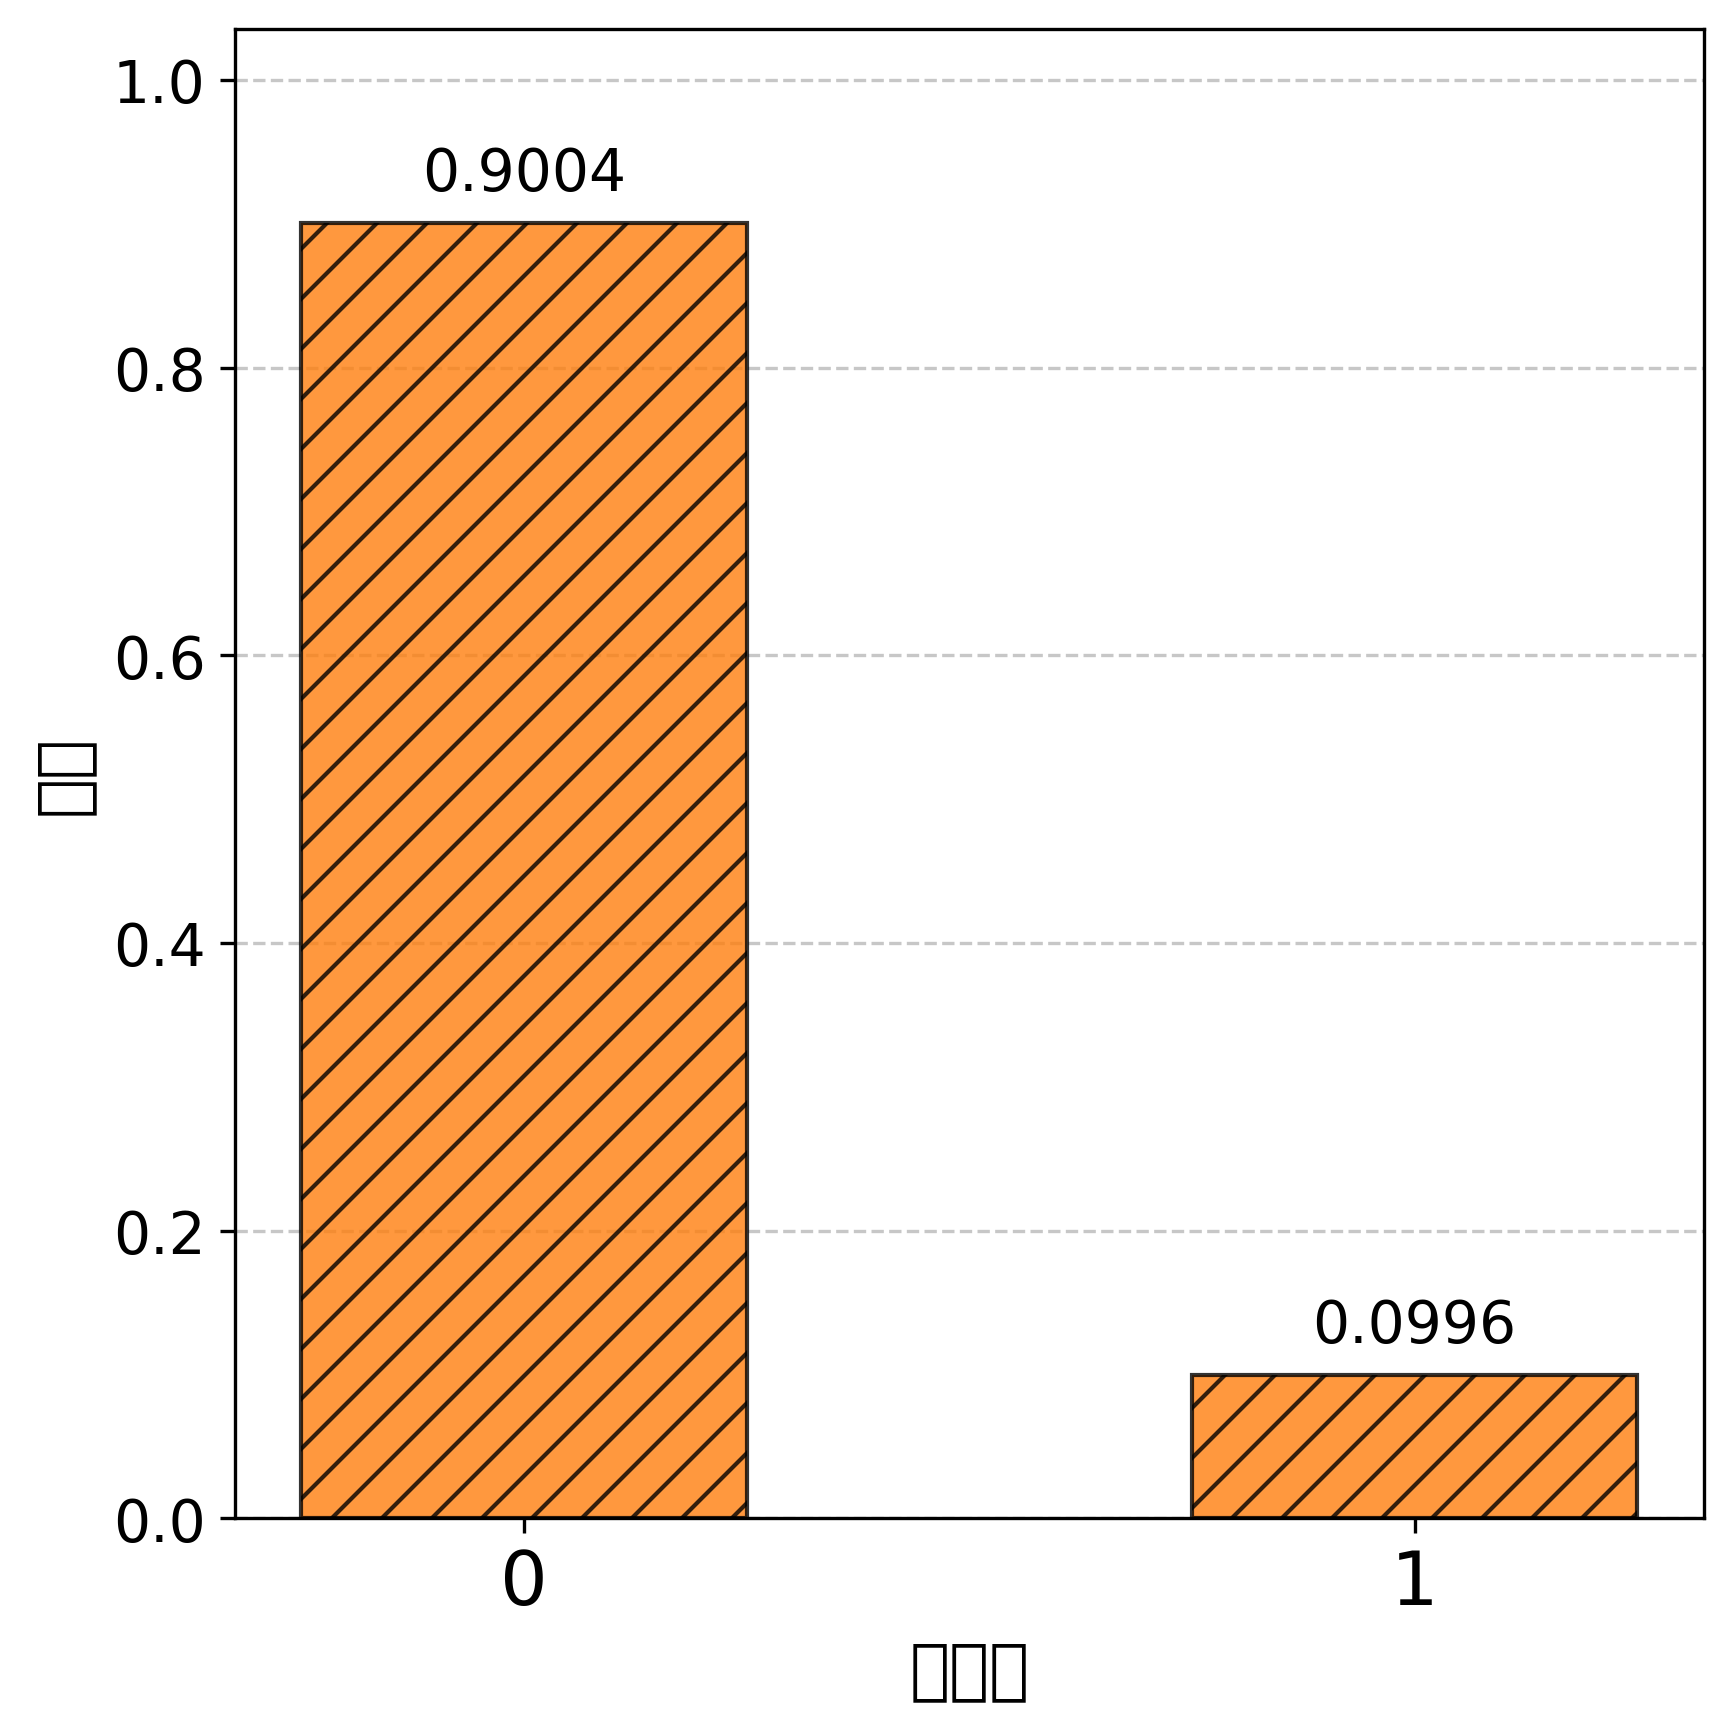

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from mindquantum.core.circuit import Circuit, UN
from mindquantum.core.gates import H, X, RY, RX, Measure, PhaseShift
from mindquantum.algorithm.library import qft
from mindquantum.simulator import Simulator

# ==================== 1. 参数设置 ====================
num_qpe_qubits = 2       
num_solution_qubits = 1  
num_auxiliary_qubits = 1 
total_qubits = 4         

# ==================== 2. 模块化构建 ====================
circ_prep = Circuit()

circ_qpe = Circuit()
circ_qpe += UN(H, range(num_qpe_qubits)) 
for k in range(num_qpe_qubits):
    tau = np.pi * (2**(k - 1))  
    circ_qpe += PhaseShift(1.5 * tau).on(k)
    circ_qpe += RX(-tau).on(2, k)

circ_iqft_std = qft([1, 0]).hermitian()

# ==================== 全通用穷举求逆 ====================
circ_inv = Circuit()
qc = [0, 1]  
qs = 3       
C = 1.0 
for k in range(1, 2**num_qpe_qubits):  
    lam = float(k)
    ratio = C / lam
    if ratio > 1.0: ratio = 1.0 
    angle = 2 * np.arcsin(ratio)
    for i in range(num_qpe_qubits):
        if (k & (1 << i)) == 0:
            circ_inv += X.on(qc[i])
    circ_inv += RY(angle).on(qs, qc)
    for i in range(num_qpe_qubits):
        if (k & (1 << i)) == 0:
            circ_inv += X.on(qc[i])

# ==================== 3. 完美对称的线路组装 ====================
full_circ = circ_prep + circ_qpe + circ_iqft_std + circ_inv + circ_iqft_std.hermitian() + circ_qpe.hermitian()
full_circ += Measure('sol_q2').on(2) 
full_circ += Measure('aux_q3').on(3)

# ==================== 4. 运行与性能计时 ====================
total_shots = 100000
sim = Simulator('mqvector', total_qubits)

print(f"开始模拟 (采样 {total_shots} 次)...")
start_time = time.time()  
result = sim.sampling(full_circ, shots=total_shots)
elapsed_time = time.time() - start_time
print(f"耗时: {elapsed_time:.4f} 秒\n")

# ==================== 5. 原始数据提取与画图 ====================
valid_counts = {k: v for k, v in result.data.items() if k.startswith('1')}
total_valid_shots = sum(valid_counts.values())

if total_valid_shots > 0:
    # 直接计算相对测量概率 (完全没有任何后处理、不开根号、不缩放)
    raw_probs = np.zeros(2)
    for state, count in valid_counts.items():
        solution_state = state[1:]  
        prob = count / total_valid_shots
        raw_probs[int(solution_state, 2)] = prob
        print(f"解状态 |{solution_state}> : 采样次数 {count:>7} 次 | 相对测量概率 {prob:>6.2%}")
        
    print(f"\n辅助比特成功率 P(success): {total_valid_shots / total_shots:.2%}")
    
    # ==================== 6. 生成原始概率柱状图 (无对比) ====================
    print("\n正在生成图表...")
    
    labels = ['0', '1']
    
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.size'] = 14
    fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
    
    x = np.arange(len(labels))
    width = 0.5
    
    # 画单列的柱状图
    rects = ax.bar(x, raw_probs, width, color='#ff7f0e', edgecolor='black', hatch='//', alpha=0.8)
    
    # 美化图表
    ax.set_ylabel('概率', fontsize=16)
    ax.set_xlabel('量子态', fontsize=16)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=18)
    
    # Y轴留一点空间放标签
    ax.set_ylim(0, max(raw_probs) * 1.15)
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)
    
    # 自动标注数值
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.4f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 5), 
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=14)

    autolabel(rects)
    fig.tight_layout()
    
    # 自动保存并显示
    plt.savefig('HHL_Raw_Probability.png', format='png', dpi=300, bbox_inches='tight')
    plt.savefig('HHL_Raw_Probability.pdf', format='pdf', bbox_inches='tight')
    print("图片已保存至当前目录 (HHL_Raw_Probability.png 和 .pdf)")
    plt.show()

else:
    print("本次采样未获得有效解，请重试。")